<a href="https://colab.research.google.com/github/HAS926/week_3_lab/blob/main/MLP_Backprop_NumPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIML302: Deep Learning and Neural Network
## Lab 3: Building and Training an MLP from Scratch with Manual Backpropagation in NumPy

**Amity University Tashkent** | Department of Information Technology and Engineering

**Duration:** 2 hours (Session 1: guided walkthrough, 60 min | Session 2: graded exercises, 60 min)

---

### What we will do today

In this lab we build a small neural network, a **multi-layer perceptron (MLP)**, using nothing but NumPy. We will write every step ourselves:

1. the **forward pass**: how the network turns inputs into a prediction,
2. the **loss**: a number that tells us how wrong the prediction is,
3. the **backward pass (backpropagation)**: how much each weight is responsible for the error,
4. the **update**: changing each weight a little so that the error becomes smaller.

Libraries such as PyTorch do steps 3 and 4 automatically with `loss.backward()` and `optimizer.step()`. Doing them once by hand is the best way to understand what those two lines really do.

### Learning outcomes

By the end of this lab you should be able to:

1. Compute the output of a neuron and apply the chain rule by hand to find its gradients.
2. Explain why a network needs a hidden layer to solve problems such as XOR.
3. Write the forward pass of a two-layer MLP with NumPy matrix operations and state the shape of every array.
4. Derive and implement the backward pass of a two-layer MLP step by step.
5. Train the MLP with gradient descent and interpret the loss curve and decision boundary.

Only NumPy and Matplotlib are used in this lab.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.1.3


---
# Session 1: Guided Walkthrough
---

## Part 1: The NumPy tools we need

A neural network is mostly **matrix multiplication** plus a few **element-wise** operations. Before building one, let us refresh the NumPy tools we will use all the time.

### 1.1 Arrays and their shape

We store a dataset as a 2-D array: **one row per example, one column per feature**. The `.shape` attribute tells us (number of rows, number of columns).

In [4]:
X = np.array([[0.0, 0.0],
              [0.0, 1.0],
              [1.0, 0.0],
              [1.0, 1.0]])
print("X =\n", X)
print("X.shape =", X.shape, " -> 4 examples, 2 features each")

# Labels are stored as a COLUMN (N rows, 1 column), not as a flat list.
y_flat = np.array([0, 1, 1, 0])
Y = y_flat.reshape(-1, 1)          # -1 means "work out this size automatically"
print("\ny_flat.shape =", y_flat.shape, "   Y.shape =", Y.shape)
print("Y =\n", Y)

X =
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
X.shape = (4, 2)  -> 4 examples, 2 features each

y_flat.shape = (4,)    Y.shape = (4, 1)
Y =
 [[0]
 [1]
 [1]
 [0]]


We keep the labels `Y` as a column of shape $(N, 1)$ because the network output will also have shape $(N, 1)$. If one is $(N,)$ and the other $(N, 1)$, NumPy silently produces an $(N, N)$ array when we subtract them, which is a very common bug.

### 1.2 Matrix multiplication with `@`

The rule for shapes: $(N, D)$ `@` $(D, H)$ gives $(N, H)$. The two **inner** numbers must match, and they disappear. Each entry of the result is a weighted sum: row $n$ of the first matrix times column $h$ of the second.

In [ ]:
A = np.array([[1.0, 2.0],
              [3.0, 4.0],
              [5.0, 6.0]])          # shape (3, 2)
B = np.array([[1.0, 0.0, -1.0],
              [2.0, 1.0,  0.0]])    # shape (2, 3)

C = A @ B                            # (3, 2) @ (2, 3) -> (3, 3)
print("C =\n", C, "\nC.shape =", C.shape)
print("C[0, 0] = 1*1 + 2*2 =", 1 * 1 + 2 * 2)

### 1.3 Adding a bias row to every example (broadcasting)

If `Z` has shape $(N, H)$ and `b` has shape $(1, H)$, then `Z + b` adds the same bias row to **every** row of `Z`. NumPy "stretches" `b` automatically. This is called **broadcasting**.

In [ ]:
Z = np.zeros((3, 2))
b = np.array([[10.0, 20.0]])         # shape (1, 2)
print("Z + b =\n", Z + b)

### 1.4 Element-wise operations, transpose and sums

* `*`, `-`, `np.exp` work **element by element** (this is different from `@`).
* `.T` is the **transpose**: rows become columns. A $(3, 2)$ array becomes $(2, 3)$.
* `np.sum(M, axis=0, keepdims=True)` adds up the rows (down each column) and keeps the result as a row of shape $(1, \text{columns})$.

In [ ]:
M = np.array([[1.0, 2.0],
              [3.0, 4.0],
              [5.0, 6.0]])
print("M * M (element-wise) =\n", M * M)
print("\nM.T =\n", M.T, "  shape", M.T.shape)
print("\nsum over rows:", np.sum(M, axis=0, keepdims=True), "  shape", np.sum(M, axis=0, keepdims=True).shape)

## Part 2: One neuron, the chain rule and gradient descent

### 2.1 What a neuron computes

A neuron with two inputs $x_1, x_2$ does two things:

1. **Weighted sum:** $\quad z = w_1 x_1 + w_2 x_2 + b$
2. **Activation:** $\quad a = \sigma(z) = \dfrac{1}{1 + e^{-z}}$

The weights $w_1, w_2$ say how important each input is, and the bias $b$ shifts the result up or down. The **sigmoid** function $\sigma$ squeezes any number into the range $(0, 1)$, so we can read $a$ as "the probability that the answer is 1".

The sigmoid has a very convenient derivative:

$$
\sigma'(z) = \sigma(z)\,\big(1 - \sigma(z)\big) = a\,(1 - a)
$$

So once we know the output $a$, its derivative is just `a * (1 - a)`. Let us plot both.

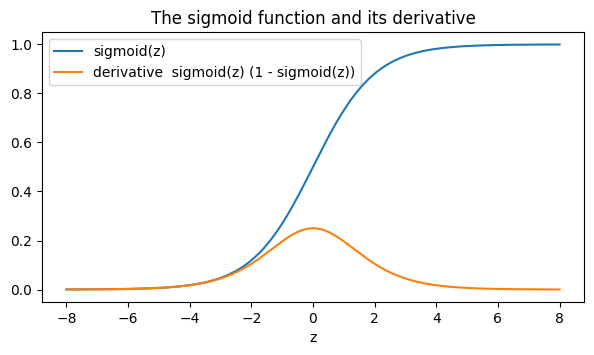

In [5]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z_values = np.linspace(-8, 8, 200)
s = sigmoid(z_values)

plt.figure(figsize=(7, 3.5))
plt.plot(z_values, s, label="sigmoid(z)")
plt.plot(z_values, s * (1 - s), label="derivative  sigmoid(z) (1 - sigmoid(z))")
plt.xlabel("z")
plt.legend()
plt.title("The sigmoid function and its derivative")
plt.show()

Two things to notice:

* For large positive $z$ the output is close to 1; for large negative $z$ it is close to 0.
* The derivative is largest (0.25) at $z = 0$ and almost 0 far away from 0. A neuron whose $z$ is very large or very small learns slowly because its gradient is tiny.

### 2.2 Measuring the error: the loss

Suppose the correct answer is $y$ and the neuron outputs $a$. We measure the error with the **squared error**:

$$
L = (a - y)^2
$$

If $a = y$ then $L = 0$. The further $a$ is from $y$, the larger $L$ becomes. **Training means changing $w_1, w_2, b$ so that $L$ becomes small.**

### 2.3 Which way should each weight move? Gradients

The derivative $\dfrac{\partial L}{\partial w_1}$ answers the question: *if I increase $w_1$ a tiny bit, does the loss go up or down, and how fast?*

* If $\dfrac{\partial L}{\partial w_1} > 0$, increasing $w_1$ increases the loss, so we should **decrease** $w_1$.
* If $\dfrac{\partial L}{\partial w_1} < 0$, we should **increase** $w_1$.

Both cases are covered by one rule, the **gradient descent update**:

$$
w_1 \leftarrow w_1 - \eta \, \frac{\partial L}{\partial w_1}
$$

where $\eta$ (eta) is the **learning rate**, a small positive number that controls the step size. Think of standing on a hill in fog: you feel which way the ground slopes (the gradient) and take a small step downhill.

### 2.4 Computing gradients with the chain rule

The loss depends on $w_1$ only **through a chain**:

$$
w_1 \;\longrightarrow\; z \;\longrightarrow\; a \;\longrightarrow\; L
$$

The **chain rule** says: multiply the derivatives of each link.

$$
\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w_1}
$$

Each link is easy on its own:

| Link | Local derivative | Why |
|---|---|---|
| $L = (a - y)^2$ | $\dfrac{\partial L}{\partial a} = 2(a - y)$ | power rule |
| $a = \sigma(z)$ | $\dfrac{\partial a}{\partial z} = a(1 - a)$ | sigmoid derivative |
| $z = w_1 x_1 + w_2 x_2 + b$ | $\dfrac{\partial z}{\partial w_1} = x_1, \quad \dfrac{\partial z}{\partial w_2} = x_2, \quad \dfrac{\partial z}{\partial b} = 1$ | only one term depends on each variable |

We compute them **from right to left** (from the loss backwards), which is why the algorithm is called **backpropagation**. It is convenient to first compute $\dfrac{\partial L}{\partial z}$ once and then reuse it for $w_1$, $w_2$ and $b$.

Let us do this with actual numbers. In the code, `dL_dw1` means $\dfrac{\partial L}{\partial w_1}$, and so on.

In [ ]:
# Inputs, target and starting parameters
x1, x2 = 1.0, 2.0
y = 1.0
w1, w2, b = 0.5, -0.4, 0.1

# ---------- Forward pass: left to right ----------
z = w1 * x1 + w2 * x2 + b
a = sigmoid(z)
L = (a - y) ** 2
print("FORWARD")
print(f"  z = {w1}*{x1} + ({w2})*{x2} + {b} = {z:.4f}")
print(f"  a = sigmoid(z)                = {a:.4f}")
print(f"  L = (a - y)^2                 = {L:.4f}")

# ---------- Backward pass: right to left ----------
dL_da = 2 * (a - y)            # link 1
da_dz = a * (1 - a)            # link 2
dL_dz = dL_da * da_dz          # chain rule: combine links 1 and 2
dL_dw1 = dL_dz * x1            # link 3 for w1
dL_dw2 = dL_dz * x2            # link 3 for w2
dL_db = dL_dz * 1.0            # link 3 for b

print("\nBACKWARD")
print(f"  dL/da  = 2(a - y)       = {dL_da:.4f}")
print(f"  da/dz  = a(1 - a)       = {da_dz:.4f}")
print(f"  dL/dz  = dL/da * da/dz  = {dL_dz:.4f}")
print(f"  dL/dw1 = dL/dz * x1     = {dL_dw1:.4f}")
print(f"  dL/dw2 = dL/dz * x2     = {dL_dw2:.4f}")
print(f"  dL/db  = dL/dz * 1      = {dL_db:.4f}")

**Interpreting the result.** The target is $y = 1$ but the output is only about 0.45, so the neuron should output something larger. All three gradients are negative, so the update rule will **increase** $w_1$, $w_2$ and $b$. $w_2$ gets the largest change because its input $x_2 = 2$ is the largest: inputs with a bigger value have more influence on $z$, so they receive more of the blame.

### 2.5 Taking gradient descent steps

Let us apply the update rule once and check that the loss really goes down, and then repeat it many times.

In [ ]:
learning_rate = 0.5

w1_new = w1 - learning_rate * dL_dw1
w2_new = w2 - learning_rate * dL_dw2
b_new = b - learning_rate * dL_db

L_new = (sigmoid(w1_new * x1 + w2_new * x2 + b_new) - y) ** 2
print(f"Loss before the step: {L:.4f}")
print(f"Loss after  the step: {L_new:.4f}")

In [ ]:
# Repeat: forward, backward, update
w1, w2, b = 0.5, -0.4, 0.1
losses = []
for step in range(30):
    # forward
    z = w1 * x1 + w2 * x2 + b
    a = sigmoid(z)
    L = (a - y) ** 2
    losses.append(L)
    # backward
    dL_dz = 2 * (a - y) * a * (1 - a)
    # update
    w1 -= learning_rate * dL_dz * x1
    w2 -= learning_rate * dL_dz * x2
    b -= learning_rate * dL_dz

print(f"final output a = {a:.4f} (target y = {y}),  final loss = {losses[-1]:.5f}")
plt.plot(losses, marker="o", markersize=3)
plt.xlabel("step"); plt.ylabel("loss")
plt.title("One neuron learning a single example")
plt.show()

This loop, **forward, backward, update, repeat**, is the whole idea of training a neural network. Everything else in this lab is the same loop applied to a bigger network and many examples at once.

## Part 3: Why one neuron is not enough: the XOR problem

XOR ("exclusive or") outputs 1 when **exactly one** of the two inputs is 1:

| $x_1$ | $x_2$ | $y$ |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

A single sigmoid neuron outputs more than 0.5 when $w_1 x_1 + w_2 x_2 + b > 0$ and less than 0.5 otherwise. The border $w_1 x_1 + w_2 x_2 + b = 0$ is a **straight line**. So a single neuron can only separate the classes with one straight line.

Look at the plot below: the two class-1 points are on one diagonal and the two class-0 points on the other. **No single straight line** can put both class-1 points on one side and both class-0 points on the other. We need a network that can draw a curved or combined boundary, and that is exactly what a **hidden layer** gives us.

In [ ]:
X_xor = np.array([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0]])
Y_xor = np.array([[0.0], [1.0], [1.0], [0.0]])

plt.figure(figsize=(4.5, 5.2))
for label, marker in [(0, "o"), (1, "s")]:
    rows = Y_xor[:, 0] == label
    plt.scatter(X_xor[rows, 0], X_xor[rows, 1], s=200, marker=marker, label=f"class {label}", edgecolors="k")
plt.plot([-0.25, 0.75], [0.75, -0.25], "k--", alpha=0.6, label="one attempt: (1, 1) is on the wrong side")
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("XOR: no straight line separates the classes")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.show()

## Part 4: The MLP forward pass

### 4.1 The architecture

We use a network with **2 inputs, 4 hidden neurons and 1 output neuron** (a "2-4-1" MLP):

```
   input layer          hidden layer              output layer
   (2 values)           (4 neurons)               (1 neuron)

                           h1
      x1  ------>          h2          ------>       y_hat
      x2  ------>          h3
                           h4

   every input is connected    every hidden neuron is connected
   to every hidden neuron      to the output neuron
```

Every hidden neuron is exactly the neuron from Part 2: a weighted sum of the inputs followed by a sigmoid. The output neuron is also the same kind of neuron, but its inputs are the 4 hidden activations instead of $x_1, x_2$.

Instead of writing a separate $w$ for every connection, we collect them in matrices:

| Parameter | Meaning | Shape |
|---|---|---|
| `W1` | weights from the 2 inputs to the 4 hidden neurons | $(2, 4)$ |
| `b1` | one bias per hidden neuron | $(1, 4)$ |
| `W2` | weights from the 4 hidden neurons to the output | $(4, 1)$ |
| `b2` | bias of the output neuron | $(1, 1)$ |

Column $j$ of `W1` holds the two weights of hidden neuron $j$. In total the network has $2 \cdot 4 + 4 + 4 \cdot 1 + 1 = 17$ parameters.

### 4.2 Processing all examples at once

We could loop over the examples one by one, but NumPy is much faster (and the code shorter) if we process the whole batch of $N$ examples with matrix multiplication. With $X$ of shape $(N, 2)$:

| Step | Formula | Code | Shape |
|---|---|---|---|
| hidden weighted sums | $Z_1 = X W_1 + b_1$ | `Z1 = X @ W1 + b1` | $(N, 4)$ |
| hidden activations | $A_1 = \sigma(Z_1)$ | `A1 = sigmoid(Z1)` | $(N, 4)$ |
| output weighted sum | $Z_2 = A_1 W_2 + b_2$ | `Z2 = A1 @ W2 + b2` | $(N, 1)$ |
| output (prediction) | $A_2 = \sigma(Z_2)$ | `A2 = sigmoid(Z2)` | $(N, 1)$ |

Row $n$ of every array belongs to example $n$. For a whole batch, we use the **mean squared error (MSE)**, the average of the squared errors of all examples:

$$
L = \frac{1}{N}\sum_{n=1}^{N} \big(A_{2,n} - Y_n\big)^2
$$

### 4.3 Initialising the parameters

* **Weights** start as small **random** numbers. If all weights started equal (for example all zero), every hidden neuron would compute exactly the same thing, receive exactly the same update, and they would stay identical forever. Random starting values make the neurons different so that each can learn something different.
* **Biases** can safely start at zero.

We use a random generator with a fixed **seed** so that everybody in the class gets the same numbers.

In [ ]:
def init_params(n_inputs, n_hidden, seed=0):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0.0, 1.0, size=(n_inputs, n_hidden))
    b1 = np.zeros((1, n_hidden))
    W2 = rng.normal(0.0, 1.0, size=(n_hidden, 1))
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2


W1, b1, W2, b2 = init_params(n_inputs=2, n_hidden=4, seed=0)
print("W1 shape", W1.shape, "  b1 shape", b1.shape, "  W2 shape", W2.shape, "  b2 shape", b2.shape)
print("W1 =\n", W1)
print("WW =\n", W2)

### 4.4 Running the forward pass step by step

Let us push the 4 XOR examples through the untrained network and look at the shape of every intermediate array.

In [ ]:
X, Y = X_xor, Y_xor
N = X.shape[0]

Z1 = X @ W1 + b1
A1 = sigmoid(Z1)
Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)

print("X  shape", X.shape)
print("Z1 shape", Z1.shape, "  (one row per example, one column per hidden neuron)")
print("A1 shape", A1.shape)
print("Z2 shape", Z2.shape)
print("A2 shape", A2.shape, "  (one prediction per example)")

loss = np.mean((A2 - Y) ** 2)
print("\nPredictions of the untrained network:", A2.ravel())
print("Targets:                             ", Y.ravel())
print(f"MSE loss = {loss:.4f}")

The untrained network gives more or less random predictions. Now we put the forward pass into a function so we can reuse it. It returns the hidden activations `A1` as well as the output `A2`, because the backward pass will need both.

In [ ]:
def mse_loss(A2, Y):
    return np.mean((A2 - Y) ** 2)


def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return A1, A2


A1, A2 = forward(X_xor, W1, b1, W2, b2)
print("loss =", mse_loss(A2, Y_xor))

## Part 5: The MLP backward pass, step by step

### 5.1 The big picture

The forward pass is a chain of simple steps:

$$
X \;\xrightarrow{W_1,\,b_1}\; Z_1 \;\xrightarrow{\sigma}\; A_1 \;\xrightarrow{W_2,\,b_2}\; Z_2 \;\xrightarrow{\sigma}\; A_2 \;\longrightarrow\; L
$$

The backward pass walks along the same chain **in the opposite direction**, from $L$ back to $W_1$. At each step we use the chain rule exactly as in Part 2:

> gradient with respect to something = (gradient with respect to the next thing in the chain) $\times$ (local derivative)

We will write `dA2` for $\partial L / \partial A_2$, `dZ2` for $\partial L / \partial Z_2$, and so on.

**The golden rule of shapes:** the gradient of a variable always has **the same shape** as the variable itself. `dW1` has the shape of `W1`, `dA1` has the shape of `A1`, etc. We will use this rule to decide where to put transposes.

### 5.2 The output layer (steps 1 to 4)

**Step 1: loss to prediction.** $L = \frac{1}{N}\sum_n (A_{2,n} - Y_n)^2$. The derivative for each example is $2(A_2 - Y)$, and the $\frac{1}{N}$ from the average stays:

$$
\texttt{dA2} = \frac{2}{N}\,(A_2 - Y) \qquad \text{shape } (N, 1)
$$

**Step 2: through the output sigmoid.** Same as in Part 2: multiply by the sigmoid derivative $A_2(1 - A_2)$, element by element:

$$
\texttt{dZ2} = \texttt{dA2} * A_2 (1 - A_2) \qquad \text{shape } (N, 1)
$$

**Step 3: gradient of the output weights.** In Part 2 we had $\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z} \cdot x$: *(gradient of $z$) times (the input that was multiplied by $w$)*. Here the inputs of the output neuron are the hidden activations $A_1$. For one example, the gradient for weight $j$ is $\texttt{dZ2} \cdot A_{1,j}$, and over the whole batch we **add up** the contributions of all examples. The matrix product does exactly this adding up:

$$
\texttt{dW2} = A_1^{\top}\, \texttt{dZ2} \qquad (4, N) \;@\; (N, 1) \;\rightarrow\; (4, 1) \;\text{ which is the shape of } W_2
$$

**Step 4: gradient of the output bias.** In Part 2, $\frac{\partial L}{\partial b} = \frac{\partial L}{\partial z}$. The same bias was used for every example, so we add up `dZ2` over all examples (all rows):

$$
\texttt{db2} = \sum_{n} \texttt{dZ2}_n \qquad \text{shape } (1, 1)
$$

### 5.3 The hidden layer (steps 5 to 7)

**Step 5: sending the error back to the hidden neurons.** $Z_2 = A_1 W_2 + b_2$, so hidden neuron $j$ influenced the output through its weight $W_{2,j}$. A hidden neuron with a large weight gets a large share of the blame:

$$
\texttt{dA1} = \texttt{dZ2}\; W_2^{\top} \qquad (N, 1) \;@\; (1, 4) \;\rightarrow\; (N, 4) \;\text{ which is the shape of } A_1
$$

**Step 6: through the hidden sigmoid.** Exactly like step 2:

$$
\texttt{dZ1} = \texttt{dA1} * A_1 (1 - A_1) \qquad \text{shape } (N, 4)
$$

**Step 7: gradients of the hidden weights and biases.** Exactly like steps 3 and 4, but now the input of the layer is $X$:

$$
\texttt{dW1} = X^{\top}\, \texttt{dZ1} \quad (2, N) \;@\; (N, 4) \rightarrow (2, 4), \qquad \texttt{db1} = \sum_n \texttt{dZ1}_n \quad (1, 4)
$$

### 5.4 Summary table

| Step | Code | Shape |
|---|---|---|
| 1 | `dA2 = 2 * (A2 - Y) / N` | $(N, 1)$ |
| 2 | `dZ2 = dA2 * A2 * (1 - A2)` | $(N, 1)$ |
| 3 | `dW2 = A1.T @ dZ2` | $(4, 1)$ like `W2` |
| 4 | `db2 = np.sum(dZ2, axis=0, keepdims=True)` | $(1, 1)$ like `b2` |
| 5 | `dA1 = dZ2 @ W2.T` | $(N, 4)$ like `A1` |
| 6 | `dZ1 = dA1 * A1 * (1 - A1)` | $(N, 4)$ |
| 7 | `dW1 = X.T @ dZ1`, `db1 = np.sum(dZ1, axis=0, keepdims=True)` | $(2, 4)$ and $(1, 4)$ |

Notice the pattern: the output layer (steps 2 to 4) and the hidden layer (steps 6 and 7) use **the same three formulas**. Once you understand one layer, you understand them all.

Let us run the seven steps on the XOR data and print every shape.

In [ ]:
X, Y = X_xor, Y_xor
N = X.shape[0]
A1, A2 = forward(X, W1, b1, W2, b2)

# ----- output layer -----
dA2 = 2 * (A2 - Y) / N                           # step 1
dZ2 = dA2 * A2 * (1 - A2)                        # step 2
dW2 = A1.T @ dZ2                                 # step 3
db2 = np.sum(dZ2, axis=0, keepdims=True)         # step 4

# ----- hidden layer -----
dA1 = dZ2 @ W2.T                                 # step 5
dZ1 = dA1 * A1 * (1 - A1)                        # step 6
dW1 = X.T @ dZ1                                  # step 7
db1 = np.sum(dZ1, axis=0, keepdims=True)         # step 7

for name, grad, param in [("W1", dW1, W1), ("b1", db1, b1), ("W2", dW2, W2), ("b2", db2, b2)]:
    status = "OK" if grad.shape == param.shape else "SHAPE MISMATCH"
    print(f"d{name}: shape {str(grad.shape):7s}  parameter {name}: shape {str(param.shape):7s}  {status}")

print("\ndW2 =\n", dW2)

### 5.5 Common mistakes to avoid

| Mistake | What goes wrong |
|---|---|
| Using `*` where `@` is needed (or the opposite) | `@` is for combining layers (steps 3, 5, 7); `*` is for activations (steps 2, 6) |
| Forgetting a transpose `.T` | usually a shape error; check the golden rule of shapes |
| Forgetting `/ N` in step 1 | gradients become $N$ times too large; training becomes unstable |
| Labels of shape $(N,)$ instead of $(N, 1)$ | `A2 - Y` becomes an $(N, N)$ matrix, and the results are silently wrong |
| Forgetting `axis=0` in the bias sums | the sum is taken over **everything**, giving a single number with the wrong shape |

Now we put the seven steps into a function.

In [ ]:
def backward(X, Y, A1, A2, W2):
    N = X.shape[0]
    # output layer
    dA2 = 2 * (A2 - Y) / N
    dZ2 = dA2 * A2 * (1 - A2)
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    # hidden layer
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * A1 * (1 - A1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

## Part 6: Training the MLP

### 6.1 The training loop

Training repeats the same four steps from Part 2 many times. One pass over the whole dataset is called an **epoch**. Here every epoch uses all examples at once (this is called **full-batch gradient descent**):

1. **Forward:** compute the predictions `A1, A2`.
2. **Loss:** compute the MSE (only for monitoring; the update does not need its value).
3. **Backward:** compute the four gradients.
4. **Update:** move every parameter a small step against its gradient.

In [ ]:
def accuracy(A2, Y):
    # A prediction counts as class 1 when the output is above 0.5
    predictions = (A2 > 0.5).astype(float)
    return np.mean(predictions == Y)


def train(X, Y, n_hidden=4, learning_rate=2.0, epochs=5000, seed=0, print_every=1000):
    W1, b1, W2, b2 = init_params(X.shape[1], n_hidden, seed)
    losses = []
    for epoch in range(epochs):
        A1, A2 = forward(X, W1, b1, W2, b2)                  # 1. forward
        loss = mse_loss(A2, Y)                               # 2. loss
        losses.append(loss)
        dW1, db1, dW2, db2 = backward(X, Y, A1, A2, W2)      # 3. backward
        W1 = W1 - learning_rate * dW1                        # 4. update
        b1 = b1 - learning_rate * db1
        W2 = W2 - learning_rate * dW2
        b2 = b2 - learning_rate * db2
        if print_every and epoch % print_every == 0:
            print(f"epoch {epoch:5d}   loss {loss:.4f}   accuracy {accuracy(A2, Y):.2f}")
    return (W1, b1, W2, b2), losses

### 6.2 Solving XOR

In [ ]:
params_xor, losses_xor = train(X_xor, Y_xor, n_hidden=4, learning_rate=2.0, epochs=5000)

W1, b1, W2, b2 = params_xor
_, A2 = forward(X_xor, W1, b1, W2, b2)
print("\n x1  x2 | target | prediction")
for x, t, p in zip(X_xor, Y_xor, A2):
    print(f" {x[0]:.0f}   {x[1]:.0f}  |   {t[0]:.0f}    |   {p[0]:.3f}")

plt.plot(losses_xor)
plt.xlabel("epoch"); plt.ylabel("MSE loss")
plt.title("Training the 2-4-1 MLP on XOR")
plt.show()

The network now outputs values close to 0 for $(0,0)$ and $(1,1)$ and close to 1 for the other two inputs: the hidden layer has solved a problem that a single neuron cannot.

Notice the shape of the loss curve: it stays almost flat for a while and then drops quickly. At the start the gradients are small and the network needs some time to find a good direction. This is normal.

### 6.3 A bigger example: points inside a circle

Now a more realistic dataset: 200 random points in a square. A point belongs to class 1 if it lies **inside a circle** around the origin, otherwise to class 0. Again, no straight line can separate the classes.

The helper `plot_decision_boundary` colours every location of the plane by the class the network would predict there. You do not need to understand every line of it.

In [ ]:
def make_circle_data(n_points=200, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-1, 1, size=(n_points, 2))
    inside = (X[:, 0] ** 2 + X[:, 1] ** 2) < 0.5
    Y = inside.astype(float).reshape(-1, 1)
    return X, Y


def plot_decision_boundary(params, X, Y, title=""):
    W1, b1, W2, b2 = params
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    _, probs = forward(grid, W1, b1, W2, b2)
    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, probs.reshape(xx.shape), levels=[0, 0.5, 1], alpha=0.25, colors=["tab:blue", "tab:orange"])
    plt.scatter(X[:, 0], X[:, 1], c=Y[:, 0], cmap="coolwarm", s=15, edgecolors="k", linewidths=0.3)
    plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
    plt.title(title)
    plt.grid(False)
    plt.show()


X_circle, Y_circle = make_circle_data(200, seed=0)
print("X_circle shape", X_circle.shape, "  Y_circle shape", Y_circle.shape)

params_circle, losses_circle = train(X_circle, Y_circle, n_hidden=8, learning_rate=2.0, epochs=3000)

plt.plot(losses_circle)
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.title("Training on the circle data")
plt.show()

_, A2 = forward(X_circle, *params_circle)
plot_decision_boundary(params_circle, X_circle, Y_circle,
                       title=f"2-8-1 MLP on circle data: accuracy {accuracy(A2, Y_circle):.2f}")

The network has learned a round-ish region for class 1. Each hidden neuron draws one straight line; the output neuron combines 8 such lines into a closed shape.

### 6.4 The effect of the learning rate

The learning rate $\eta$ is the size of each downhill step.

* **Too small:** the steps are tiny and training takes a very long time.
* **Well chosen:** the loss falls steadily.
* **Too large:** the steps overshoot. The weights can become so large that the sigmoid neurons land in their flat regions (Part 2.1), where the gradient is almost zero. The network then gets stuck at a high loss and stops learning.

Run the cell and compare the three curves.

In [ ]:
plt.figure(figsize=(6.5, 4))
for lr in [0.1, 2.0, 50.0]:
    _, losses = train(X_circle, Y_circle, n_hidden=8, learning_rate=lr, epochs=1000, print_every=0)
    plt.plot(losses, label=f"learning rate = {lr}")
plt.xlabel("epoch"); plt.ylabel("MSE loss")
plt.title("Same network, different learning rates")
plt.legend()
plt.show()

---
## Session 1 summary

The whole of backpropagation for one layer fits in three lines. If `dZ` is the gradient arriving at the weighted sum of a layer and `A_in` is the input of that layer:

```
dW    = A_in.T @ dZ                          # gradient of the weights
db    = np.sum(dZ, axis=0, keepdims=True)    # gradient of the bias
dA_in = dZ @ W.T                             # gradient passed back to the previous layer
```

and to go back through a sigmoid we multiply by `A * (1 - A)`.

The training recipe is always the same:

1. **Forward:** compute the prediction, keeping the intermediate results.
2. **Loss:** measure the error.
3. **Backward:** apply the chain rule from the loss back to every parameter.
4. **Update:** `parameter = parameter - learning_rate * gradient`.
5. Repeat.

In PyTorch, steps 3 and 4 are `loss.backward()` and `optimizer.step()`. Now you know what they compute.

---
# Session 2: Graded Exercises (80 marks)
---

### Instructions

* Work **independently**. You may reuse any function from Session 1 (run all Session 1 cells first).
* Write your code where you see `# YOUR CODE HERE` and delete the line `raise NotImplementedError()`.
* Do **not** change function names or their arguments: they are used by the check cells.
* After each exercise there is a **check cell**. Run it. `PASS` means your code gives the expected result on the test case. The final marks are awarded by the instructor, who will also read your code and written answers.
* Use only NumPy and Matplotlib.
* Before submitting: *Kernel > Restart & Run All*, make sure there are no errors, and save the notebook as `Lab3_<EnrolmentNumber>.ipynb`.

### Marks breakdown

| Exercise | Topic | Marks |
|---|---|---|
| 1 | One neuron by hand | 10 |
| 2 | Two more activation functions: ReLU and tanh | 10 |
| 3 | Forward pass of an MLP with a tanh hidden layer | 15 |
| 4 | Backward pass of the tanh MLP | 25 |
| 5 | Training on the two-moons dataset | 20 |
| | **Total** | **80** |

In [6]:
# Helper used by the check cells. Do not modify.
def run_check(name, fn):
    try:
        ok, msg = fn()
        print(f"[{'PASS' if ok else 'FAIL'}] {name}: {msg}")
    except NotImplementedError:
        print(f"[NOT DONE] {name}: not implemented yet")
    except NameError as e:
        print(f"[NOT DONE] {name}: variable not defined yet ({e})")
    except Exception as e:
        print(f"[ERROR] {name}: {type(e).__name__}: {e}")

## Exercise 1: One neuron by hand (10 marks)

A neuron has two inputs, a sigmoid activation and the squared-error loss $L = (a - y)^2$, exactly as in Part 2. Use these values:

$$x_1 = 0.5, \quad x_2 = -1.0, \quad w_1 = 0.8, \quad w_2 = 0.2, \quad b = -0.1, \quad y = 0$$

**1a. (4 marks)** Compute the forward pass: store the results in `z`, `a` and `L`.

**1b. (6 marks)** Compute the backward pass with the chain rule: store the results in `dL_da`, `dL_dz`, `dL_dw1`, `dL_dw2` and `dL_db`. Print all values.

In [8]:
x1, x2 = 0.5, -1.0
w1, w2, b = 0.8, 0.2, -0.1
y = 0.0
z = a = L = dL_da = dL_dz = dL_dw1 = dL_dw2 = dL_db = None   # you will fill these in

# ----- 1a: forward -----
z = w1 * x1 + w2 * x2 + b
a = sigmoid(z)
L = (a - y) ** 2
print("FORWARD")
print(f"  z = {w1}*{x1} + ({w2})*{x2} + {b} = {z:.4f}")
print(f"  a = sigmoid(z)                = {a:.4f}")
print(f"  L = (a - y)^2                 = {L:.4f}")

# ----- 1b: backward -----
dL_da = 2 * (a - y)            #  1
da_dz = a * (1 - a)            #  2
dL_dz = dL_da * da_dz          #  1 & 2
dL_dw1 = dL_dz * x1            #  3 for w1
dL_dw2 = dL_dz * x2            #  3 for w2
dL_db = dL_dz * 1.0            #  3 for b

print("\nBACKWARD")
print(f"  dL/da  = 2(a - y)       = {dL_da:.4f}")
print(f"  da/dz  = a(1 - a)       = {da_dz:.4f}")
print(f"  dL/dz  = dL/da * da/dz  = {dL_dz:.4f}")
print(f"  dL/dw1 = dL/dz * x1     = {dL_dw1:.4f}")
print(f"  dL/dw2 = dL/dz * x2     = {dL_dw2:.4f}")
print(f"  dL/db  = dL/dz * 1      = {dL_db:.4f}")

FORWARD
  z = 0.8*0.5 + (0.2)*-1.0 + -0.1 = 0.1000
  a = sigmoid(z)                = 0.5250
  L = (a - y)^2                 = 0.2756

BACKWARD
  dL/da  = 2(a - y)       = 1.0500
  da/dz  = a(1 - a)       = 0.2494
  dL/dz  = dL/da * da/dz  = 0.2618
  dL/dw1 = dL/dz * x1     = 0.1309
  dL/dw2 = dL/dz * x2     = -0.2618
  dL/db  = dL/dz * 1      = 0.2618


In [9]:
# Check cell for Exercise 1. Do not modify.
def _ref_1():
    z_ = 0.8 * 0.5 + 0.2 * (-1.0) - 0.1
    a_ = 1 / (1 + np.exp(-z_))
    dz_ = 2 * a_ * a_ * (1 - a_)
    return z_, a_, a_ ** 2, 2 * a_, dz_, dz_ * 0.5, -dz_, dz_

def _check_1a():
    if z is None: raise NotImplementedError
    r = _ref_1()
    ok = np.allclose([z, a, L], r[:3])
    return ok, "z, a and L are correct"

def _check_1b():
    if dL_db is None: raise NotImplementedError
    r = _ref_1()
    ok = np.allclose([dL_da, dL_dz, dL_dw1, dL_dw2, dL_db], r[3:])
    return ok, "all five gradients are correct"

run_check("1a forward", _check_1a)
run_check("1b backward", _check_1b)

[PASS] 1a forward: z, a and L are correct
[PASS] 1b backward: all five gradients are correct


## Exercise 2: Two more activation functions (10 marks)

Sigmoid is not the only activation function. Two very common alternatives are:

| Name | Formula | Derivative |
|---|---|---|
| ReLU | $\text{relu}(z) = \max(0, z)$ | $1$ if $z > 0$, otherwise $0$ |
| tanh | $\tanh(z)$, output in $(-1, 1)$ | $1 - \tanh^2(z)$ |

All functions must work **element by element** on NumPy arrays of any shape.

**2a. (5 marks)** Implement `relu(z)` and `relu_derivative(z)`. Hint: `np.maximum(0, z)`, and `(z > 0)` gives an array of `True`/`False` that you can convert with `.astype(float)`.

**2b. (5 marks)** Implement `tanh(z)` and `tanh_derivative(z)`. You may use `np.tanh`.

In [10]:
def relu(z):
    return np.maximum(0,z)


def relu_derivative(z):
    return (z > 0).astype(float)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z)**2

In [11]:
# Check cell for Exercise 2. Do not modify.
def _check_2a():
    zt = np.array([[-3.0, -0.1, 0.0], [0.2, 1.5, 7.0]])
    ok = np.allclose(relu(zt), [[0, 0, 0], [0.2, 1.5, 7.0]]) and np.allclose(relu_derivative(zt), [[0, 0, 0], [1, 1, 1]])
    return ok and relu(zt).shape == zt.shape, "ReLU and its derivative are correct"

def _check_2b():
    zt = np.array([[-3.0, -0.1, 0.0], [0.2, 1.5, 7.0]])
    ok = np.allclose(tanh(zt), np.tanh(zt)) and np.allclose(tanh_derivative(zt), 1 / np.cosh(zt) ** 2)
    return ok, "tanh and its derivative are correct"

run_check("2a ReLU", _check_2a)
run_check("2b tanh", _check_2b)

[PASS] 2a ReLU: ReLU and its derivative are correct
[PASS] 2b tanh: tanh and its derivative are correct


## Exercise 3: Forward pass of an MLP with a tanh hidden layer (15 marks)

From now on we change **one thing** in the Session 1 network: the hidden layer uses **tanh** instead of sigmoid. The output layer still uses **sigmoid** (so the output stays between 0 and 1), and the loss is still the MSE.

| Step | Formula | Shape |
|---|---|---|
| hidden weighted sums | $Z_1 = X W_1 + b_1$ | $(N, H)$ |
| hidden activations | $A_1 = \tanh(Z_1)$ | $(N, H)$ |
| output weighted sum | $Z_2 = A_1 W_2 + b_2$ | $(N, 1)$ |
| output | $A_2 = \sigma(Z_2)$ | $(N, 1)$ |

**3a. (5 marks)** Implement `mse(A2, Y)` that returns the mean squared error $\frac{1}{N}\sum_n (A_{2,n} - Y_n)^2$ as a single number. Do not use the Session 1 function `mse_loss`: write it yourself.

**3b. (10 marks)** Implement `forward_tanh(X, W1, b1, W2, b2)` that returns `A1, A2`.

In [ ]:
def mse(A2, Y):
    # YOUR CODE HERE
    raise NotImplementedError()


def forward_tanh(X, W1, b1, W2, b2):
    # YOUR CODE HERE
    raise NotImplementedError()
    return A1, A2

In [ ]:
# Check cell for Exercise 3. Do not modify.
_rng = np.random.default_rng(123)
_X3 = _rng.normal(size=(5, 2)); _Y3 = np.array([[0.0], [1.0], [1.0], [0.0], [1.0]])
_P3 = (_rng.normal(size=(2, 3)), _rng.normal(size=(1, 3)), _rng.normal(size=(3, 1)), _rng.normal(size=(1, 1)))

def _ref_forward(X, W1, b1, W2, b2):
    A1 = np.tanh(X @ W1 + b1)
    return A1, 1 / (1 + np.exp(-(A1 @ W2 + b2)))

def _check_3a():
    A2t = np.array([[0.2], [0.9], [0.6], [0.1], [0.5]])
    val = mse(A2t, _Y3)
    return np.isclose(val, np.mean((A2t - _Y3) ** 2)) and np.ndim(val) == 0, f"mse = {float(val):.4f}"

def _check_3b():
    A1, A2 = forward_tanh(_X3, *_P3)
    rA1, rA2 = _ref_forward(_X3, *_P3)
    ok = A1.shape == (5, 3) and A2.shape == (5, 1) and np.allclose(A1, rA1) and np.allclose(A2, rA2)
    return ok, f"A1 shape {A1.shape}, A2 shape {A2.shape}, values match reference: {np.allclose(A2, rA2)}"

run_check("3a mse", _check_3a)
run_check("3b forward_tanh", _check_3b)

## Exercise 4: Backward pass of the tanh MLP (25 marks)

Follow the seven steps of Part 5. The **only** difference from Session 1 is step 6: the hidden layer now uses tanh, whose derivative is $1 - \tanh^2(Z_1) = 1 - A_1^2$. So

$$
\texttt{dZ1} = \texttt{dA1} * (1 - A_1^2)
$$

Everything else is the same as in Session 1 (the output layer still uses sigmoid).

We split the backward pass into two functions, one per layer.

**4a. (10 marks)** `backward_output(A1, A2, Y)`: compute steps 1 to 4 and return `dZ2, dW2, db2`.

**4b. (10 marks)** `backward_hidden(X, A1, dZ2, W2)`: compute steps 5 to 7 and return `dW1, db1`.

**4c. (5 marks)** In the cell after the functions, compute all four gradients for the small network given there and print the shape of each gradient next to the shape of its parameter (as in Part 5.4).

In [ ]:
def backward_output(A1, A2, Y):
    N = Y.shape[0]
    # YOUR CODE HERE
    raise NotImplementedError()
    return dZ2, dW2, db2


def backward_hidden(X, A1, dZ2, W2):
    # YOUR CODE HERE
    raise NotImplementedError()
    return dW1, db1


def backward_tanh(X, Y, A1, A2, W2):
    # Given: combines your two functions. Do not modify.
    dZ2, dW2, db2 = backward_output(A1, A2, Y)
    dW1, db1 = backward_hidden(X, A1, dZ2, W2)
    return dW1, db1, dW2, db2

In [ ]:
# 4c: a small network with 3 inputs, 5 hidden neurons and 6 examples
rng = np.random.default_rng(7)
X_4 = rng.normal(size=(6, 3))
Y_4 = np.array([[1.0], [0.0], [0.0], [1.0], [1.0], [0.0]])
W1_4, b1_4, W2_4, b2_4 = init_params(n_inputs=3, n_hidden=5, seed=1)

# YOUR CODE HERE

In [ ]:
# Check cell for Exercise 4. Do not modify.
def _ref_backward(X, Y, A1, A2, W2):
    N = X.shape[0]
    dZ2 = 2 * (A2 - Y) / N * A2 * (1 - A2)
    dZ1 = (dZ2 @ W2.T) * (1 - A1 ** 2)
    return X.T @ dZ1, dZ1.sum(0, keepdims=True), A1.T @ dZ2, dZ2.sum(0, keepdims=True), dZ2

def _check_4a():
    A1, A2 = _ref_forward(_X3, *_P3)
    r = _ref_backward(_X3, _Y3, A1, A2, _P3[2])
    dZ2, dW2, db2 = backward_output(A1, A2, _Y3)
    ok = np.allclose(dZ2, r[4]) and np.allclose(dW2, r[2]) and dW2.shape == (3, 1) and np.allclose(db2, r[3]) and db2.shape == (1, 1)
    return ok, "dZ2, dW2 and db2 are correct (values and shapes)"

def _check_4b():
    A1, A2 = _ref_forward(_X3, *_P3)
    r = _ref_backward(_X3, _Y3, A1, A2, _P3[2])
    dW1, db1 = backward_hidden(_X3, A1, r[4], _P3[2])
    ok = np.allclose(dW1, r[0]) and dW1.shape == (2, 3) and np.allclose(db1, r[1]) and db1.shape == (1, 3)
    return ok, "dW1 and db1 are correct (values and shapes)"

def _check_4c():
    ok = dW1_4.shape == (3, 5) and db1_4.shape == (1, 5) and dW2_4.shape == (5, 1) and db2_4.shape == (1, 1)
    return ok, "all four gradients computed with the correct shapes"

run_check("4a output layer", _check_4a)
run_check("4b hidden layer", _check_4b)
run_check("4c shapes", _check_4c)

## Exercise 5: Training on the two-moons dataset (20 marks)

The cell below creates the **two-moons** dataset: two interleaving half-circles with some noise. It is split into a **training set** (used to learn the weights) and a **test set** (new points the network has never seen, used to measure how well it generalises).

In [ ]:
# Data for Exercise 5. Do not modify.
def make_moons(n_per_class, noise=0.2, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.uniform(0, np.pi, n_per_class)
    upper = np.c_[np.cos(t), np.sin(t)]                 # class 0
    lower = np.c_[1 - np.cos(t), 0.5 - np.sin(t)]       # class 1
    X = np.r_[upper, lower] + rng.normal(0, noise, size=(2 * n_per_class, 2))
    Y = np.r_[np.zeros(n_per_class), np.ones(n_per_class)].reshape(-1, 1)
    return X, Y

X_train, Y_train = make_moons(150, noise=0.2, seed=1)
X_test, Y_test = make_moons(50, noise=0.2, seed=2)
print("training set:", X_train.shape, Y_train.shape, "   test set:", X_test.shape, Y_test.shape)

plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train[:, 0], cmap="coolwarm", s=15, edgecolors="k", linewidths=0.3)
plt.title("Two-moons training data")
plt.grid(False)
plt.show()

**5a. (5 marks)** Complete `update(params, grads, learning_rate)`. Both arguments are tuples `(W1, b1, W2, b2)` and `(dW1, db1, dW2, db2)`. Return a new tuple of updated parameters using `parameter - learning_rate * gradient`.

**5b. (10 marks)** Complete `train_tanh(X, Y, n_hidden, learning_rate, epochs, seed)`. It must:

* create the parameters with `init_params` from Session 1 (already done for you),
* in every epoch: run `forward_tanh`, compute the loss with `mse` and append it to the list `losses`, run `backward_tanh`, and call `update`,
* return `params, losses`.

Then train a network with **8 hidden neurons** on the training set, store the result in `params_moons, losses_moons`, and print the training and test accuracy (use `accuracy` from Session 1). Target: **test accuracy of at least 0.95**. Hint: learning rate 1.0 and 3000 epochs work well.

**5c. (5 marks)** Plot the training loss against the epoch (with axis labels and a title). Then show the decision boundary on the **test** set. The Session 1 function `plot_decision_boundary` uses the sigmoid network, so a copy called `plot_decision_boundary_tanh` that uses `forward_tanh` is given below.

In [ ]:
def update(params, grads, learning_rate):
    W1, b1, W2, b2 = params
    dW1, db1, dW2, db2 = grads
    # YOUR CODE HERE
    raise NotImplementedError()
    return W1, b1, W2, b2


def train_tanh(X, Y, n_hidden=8, learning_rate=1.0, epochs=3000, seed=0):
    params = init_params(X.shape[1], n_hidden, seed)
    losses = []
    for epoch in range(epochs):
        # YOUR CODE HERE
        raise NotImplementedError()
    return params, losses

In [ ]:
# 5b: train on the two-moons data and report the accuracies
# YOUR CODE HERE

In [ ]:
# Given: decision boundary plot for the tanh network. Do not modify.
def plot_decision_boundary_tanh(params, X, Y, title=""):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, 200),
                         np.linspace(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, 200))
    _, probs = forward_tanh(np.c_[xx.ravel(), yy.ravel()], *params)
    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, probs.reshape(xx.shape), levels=[0, 0.5, 1], alpha=0.25, colors=["tab:blue", "tab:orange"])
    plt.scatter(X[:, 0], X[:, 1], c=Y[:, 0], cmap="coolwarm", s=15, edgecolors="k", linewidths=0.3)
    plt.title(title)
    plt.grid(False)
    plt.show()

In [ ]:
# 5c: your plots
# YOUR CODE HERE

In [ ]:
# Check cell for Exercise 5. Do not modify.
def _check_5a():
    p = (np.ones((2, 2)), np.zeros((1, 2)), np.ones((2, 1)), np.zeros((1, 1)))
    g = (np.full((2, 2), 2.0), np.full((1, 2), -1.0), np.full((2, 1), 0.5), np.full((1, 1), 4.0))
    W1, b1, W2, b2 = update(p, g, 0.1)
    ok = np.allclose(W1, 0.8) and np.allclose(b1, 0.1) and np.allclose(W2, 0.95) and np.allclose(b2, -0.4)
    return ok, "all four parameters updated correctly"

def _check_5b():
    _, A2t = forward_tanh(X_test, *params_moons)
    acc = accuracy(A2t, Y_test)
    ok = acc >= 0.95 and len(losses_moons) > 0 and losses_moons[-1] < losses_moons[0]
    return ok, f"test accuracy = {acc:.3f} (need >= 0.95), loss decreased: {losses_moons[-1] < losses_moons[0]}"

run_check("5a update", _check_5a)
run_check("5b training", _check_5b)
print("5c is marked by the instructor from your plots.")